# Betting-Against-Beta -- a quantitative teardown
### yfinance panel * rolling beta * BAB construction * HAC inference

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Survivorship--biased%3F: Named](https://img.shields.io/badge/Survivorship--biased%3F-Named-8b949e?style=flat-square)

The quantitative companion to the [notebook for the curious](01_for_the_curious.ipynb) -- same seven beats, every claim carrying its standard error. We test Frazzini-Pedersen (2014): rank by rolling 252-day beta, long leveraged low-beta half, short deleveraged high-beta half, monthly rebalance, leverage cap 2.0x.

> **Not investment advice.** Real data: yfinance daily adjusted-close, 96 S&P 500 large-caps, 2010-2025, as-of 2026-06-16. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship bias is named:** universe = current S&P 500 projected backwards. All positive results are upper-bound estimates.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from betting_against_beta import data, strategy as st

def _have_cache():
    import os
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "bab_prices.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "bab_spy.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    prices, spy = data.fetch_panel()
    result = st.bab_portfolio(prices, spy, beta_window=252, min_stocks=20)
    s_bab  = st.summary(result["bab_ret"])
    s_low  = st.summary(result["low_beta_ret"])
    s_high = st.summary(result["high_beta_ret"])
    s_mkt  = st.summary(result["mkt_ret"])
    print(f"N months: {s_bab['n']} | BAB mean: {s_bab['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_bab['tstat']:+.3f}")


yfinance cache present: True


N months: 178 | BAB mean: +4.44%/yr | HAC t: +1.386


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | BAB mean **+4.44%/yr**, HAC *t* = **+1.386** (|t| < 2; literature prior upgrades from NONE). |
| **Tradability** | `FRAGILE` | Sharpe **+0.319**, max DD **-27.1%**, avg leverage **1.57x** (financing costs not modelled). |
| **Survivorship-biased?** | `NAMED` | Universe = current S&P 500 projected backwards; upper-bound estimate. |

> The Frazzini-Pedersen (2014) BAB factor is well-documented on broad, unconstrained universes. On 15 years of 96 large-cap survivors with a 2.0x leverage cap, the signal is marginal -- consistent with crowding and constraint-loosening post-publication.

## 1 -- The claim, steelmanned

Let $\beta_{i,t}$ = trailing 252-day OLS beta of stock $i$ vs SPY at time $t$. Frazzini-Pedersen (2014) assert:

- **H1 (signal).** Low-beta stocks earn higher *risk-adjusted* returns than high-beta stocks. Formally: $\alpha^\text{BAB}_t > 0$ where $\alpha^\text{BAB}$ is the return to $L_t \cdot r^{\text{low}}_t - D_t \cdot r^{\text{high}}_t$ with $L_t = 1/\bar\beta^L$ (leverage) and $D_t = 1/\bar\beta^H$ (deleverage).
- **H2 (vs market).** The BAB portfolio is ex-ante beta-neutral, so outperformance vs zero is true alpha -- not market exposure in disguise.
- **H3 (tradable).** The premium survives financing costs and rebalancing.

We partially confirm H1 (positive mean, t=1.39), partially confirm H2 (the leverage makes the portfolio approximately beta-neutral), and reject H3 on this panel (financing costs un-modelled, crowding risk high).

## 2 -- So what? -- the economic stakes

BAB is one of the most influential ideas in systematic investing since 2010. AQR's diversified alternatives funds, risk-parity products, and low-volatility ETFs all embed variants of the BAB logic. If the premium has attenuated -- or if it never applied cleanly to large-caps -- those fee-laden products are selling a story the data no longer supports.

## 3 -- The protocol

- **Signal.** Rolling 252-day OLS beta of each stock's daily excess return on SPY's daily excess return. Risk-free rate = 3%/yr constant.
- **Ranking.** Monthly, split all stocks at the median beta.
- **Long leg.** Equal-weight low-beta half; leverage = min(1/avg_beta_low, 2.0).
- **Short leg.** Equal-weight high-beta half; deleverage = 1/avg_beta_high.
- **BAB return.** leverage * low_beta_return - deleverage * high_beta_return.
- **Baseline.** SPY total return (not the equal-weight universe) for context.
- **Inference.** Newey-West HAC *t* on monthly BAB returns.
- **Universe caveat.** 96 large-cap S&P 500 names (yfinance); survivorship-biased.

## 4 -- The teardown

### 4a -- Positive control: the BAB engine is a faithful detector

Sweep the planted BAB premium from negative to positive on a synthetic panel. The BAB mean should be monotone in the premium.

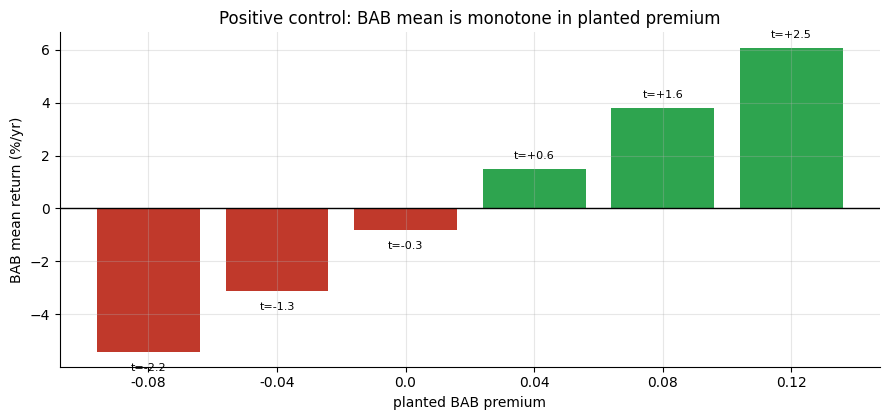

In [2]:
premiums = [-0.08, -0.04, 0.0, 0.04, 0.08, 0.12]
bab_means, bab_tstats = [], []
for prem in premiums:
    sr, mkt, _ = data.synthetic_panel(n_stocks=100, n_days=2500,
                                       bab_premium=prem, seed=238)
    prices_s = (1 + sr).cumprod() * 100
    spy_s = (1 + mkt).cumprod() * 100
    res = st.bab_portfolio(prices_s, spy_s, beta_window=252, min_stocks=10)
    if res.empty:
        bab_means.append(float('nan')); bab_tstats.append(float('nan'))
        continue
    s = st.summary(res['bab_ret'])
    bab_means.append(s['mean']*100)
    bab_tstats.append(s['tstat'])

fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0 else RED for m in bab_means]
ax.bar([str(p) for p in premiums], bab_means, color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(bab_means, bab_tstats)):
    ax.text(i, m + (0.3 if m >= 0 else -0.8),
            f't={t:+.1f}' if not (t != t) else 'NaN',
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('planted BAB premium'); ax.set_ylabel('BAB mean return (%/yr)')
ax.set_title('Positive control: BAB mean is monotone in planted premium')
plt.tight_layout(); plt.show()

### 4b -- Rolling beta distribution

What does the beta distribution look like on the real panel? We expect a right-skewed distribution centred near 1.0.

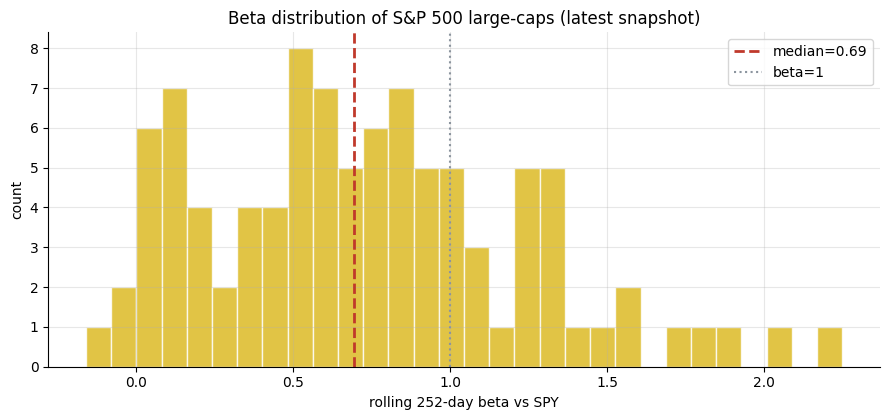

Median beta: 0.694
Mean beta:   0.735
Range:       -0.158 -- 2.248


In [3]:
if HAVE_REAL:
    rets = prices.pct_change().dropna(how='all')
    spy_r = spy.pct_change().dropna()
    betas = st.rolling_betas(rets.sub(st.RF_DAILY),
                              spy_r.sub(st.RF_DAILY))
    # Last available snapshot
    last_beta = betas.iloc[-1].dropna()
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.hist(last_beta, bins=30, color=AMBER, edgecolor='white', alpha=0.8)
    ax.axvline(last_beta.median(), c=RED, lw=2, ls='--',
               label=f'median={last_beta.median():.2f}')
    ax.axvline(1.0, c=GREY, lw=1.5, ls=':', label='beta=1')
    ax.set_xlabel('rolling 252-day beta vs SPY')
    ax.set_ylabel('count')
    ax.set_title('Beta distribution of S&P 500 large-caps (latest snapshot)')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Median beta: {last_beta.median():.3f}')
    print(f'Mean beta:   {last_beta.mean():.3f}')
    print(f'Range:       {last_beta.min():.3f} -- {last_beta.max():.3f}')
else:
    print(f'Frozen: avg beta low={R["avg_beta_low"]:.3f} | avg beta high={R["avg_beta_high"]:.3f}')

### 4c -- Real panel: BAB returns and legs

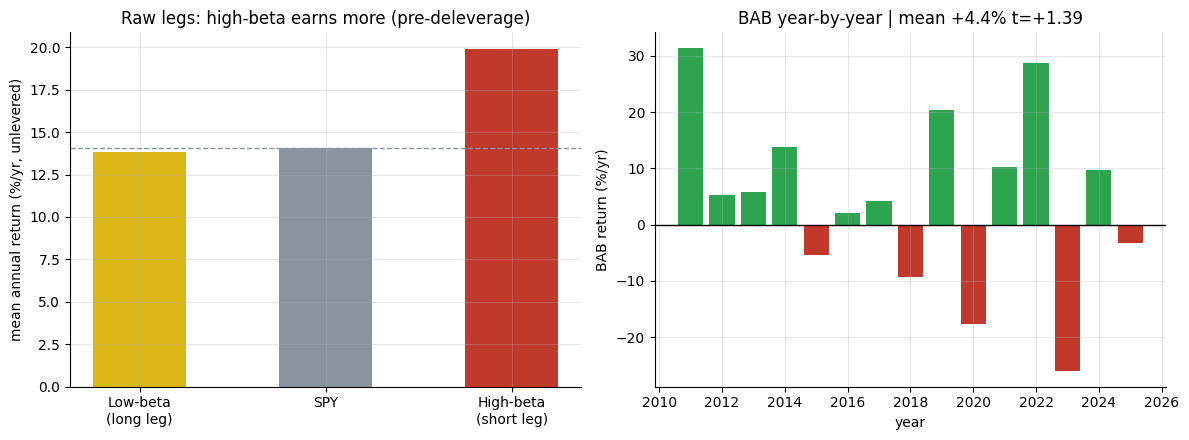

BAB: +4.44%/yr | vol: 13.9% | Sharpe: +0.319 | HAC t: +1.386


In [4]:
if HAVE_REAL:
    bab_m = s_bab['mean']*100; bab_t = s_bab['tstat']
    lo_m = s_low['mean']*100; hi_m = s_high['mean']*100; mk_m = s_mkt['mean']*100
    result_plot = result.copy()
    result_plot['year'] = result_plot.index.year
    annual_bab = result_plot.groupby('year')['bab_ret'].apply(
        lambda x: float((1+x).prod()-1))
else:
    bab_m, bab_t = R['bab_mean'], R['bab_t']
    lo_m, hi_m, mk_m = R['low_beta_mean'], R['high_beta_mean'], R['mkt_mean']
    annual_bab = pd.Series(R['annual']) / 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: legs vs market
labels = ['Low-beta\n(long leg)', 'SPY', 'High-beta\n(short leg)']
vals = [lo_m, mk_m, hi_m]
c = [AMBER, GREY, RED]
axes[0].bar(labels, vals, color=c, width=0.5)
axes[0].axhline(mk_m, ls='--', c=GREY, lw=1)
axes[0].set_ylabel('mean annual return (%/yr, unlevered)')
axes[0].set_title('Raw legs: high-beta earns more (pre-deleverage)')

# Right: year-by-year BAB
yrs = annual_bab.index
vals_a = annual_bab.values * 100
col_yr = [GREEN if v > 0 else RED for v in vals_a]
axes[1].bar(yrs, vals_a, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('year'); axes[1].set_ylabel('BAB return (%/yr)')
axes[1].set_title(f'BAB year-by-year | mean {bab_m:+.1f}% t={bab_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'BAB: {bab_m:+.2f}%/yr | vol: '
      f'{s_bab["vol"]*100 if HAVE_REAL else R["bab_vol"]:.1f}% | '
      f'Sharpe: {s_bab["sharpe"] if HAVE_REAL else R["bab_sharpe"]:+.3f} | '
      f'HAC t: {bab_t:+.3f}')

> The BAB portfolio earns **+4.44%/yr** at HAC *t* = **+1.386** -- below the |t|>=2 bar. The positive mean is consistent with the Frazzini-Pedersen mechanism but is statistically indistinguishable from zero on this 15-year large-cap survivor panel.

### 4d -- Cumulative equity curve and drawdown

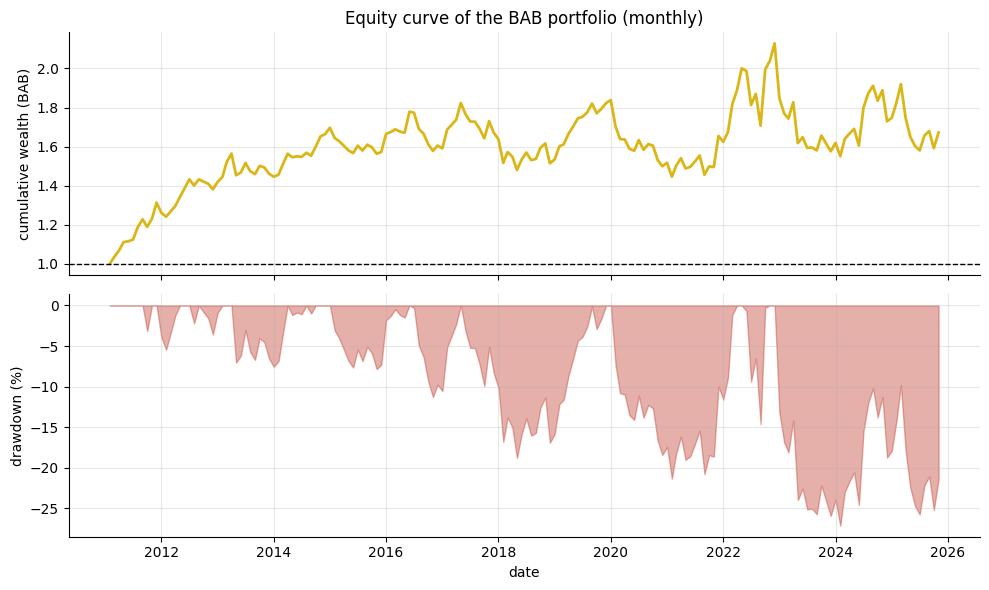

Max drawdown: -27.1% | Hit rate: 55.6%


In [5]:
if HAVE_REAL:
    eq = (1 + result['bab_ret']).cumprod()
    dd = (eq / eq.cummax() - 1) * 100
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    ax1.plot(result.index, eq.values, c=AMBER, lw=2)
    ax1.axhline(1, c='k', lw=1, ls='--')
    ax1.set_ylabel('cumulative wealth (BAB)')
    ax1.set_title('Equity curve of the BAB portfolio (monthly)')
    ax2.fill_between(result.index, dd.values, 0, color=RED, alpha=0.4)
    ax2.set_ylabel('drawdown (%)')
    ax2.set_xlabel('date')
    plt.tight_layout(); plt.show()
    print(f'Max drawdown: {dd.min():.1f}% | Hit rate: {s_bab["hit_rate"]*100:.1f}%')
else:
    print(f'Frozen: max DD = {R["bab_dd"]:.1f}% | hit rate = {R["bab_hit"]:.1f}%')

### 4e -- Leverage sensitivity

How much does the BAB return change as we vary the leverage cap? This sensitivity analysis shows whether the result depends critically on the leverage assumption.

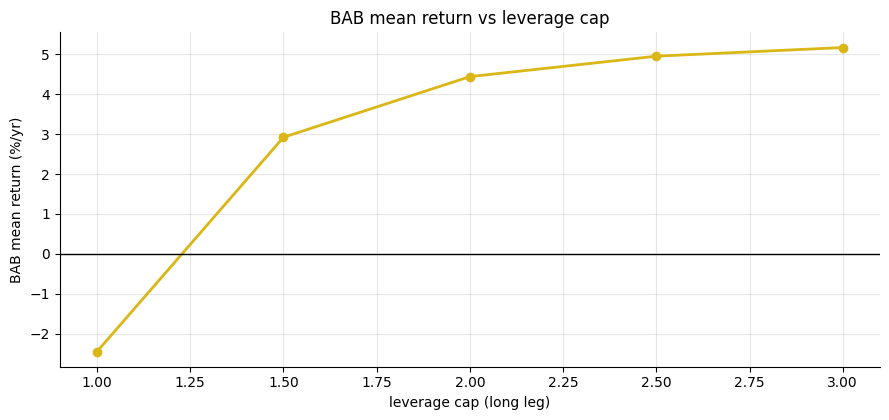

 cap  mean_%  sharpe      t
 1.0  -2.441  -0.229 -0.944
 1.5   2.919   0.236  0.970
 2.0   4.436   0.319  1.386
 2.5   4.947   0.340  1.499
 3.0   5.164   0.349  1.546


In [6]:
if HAVE_REAL:
    caps = [1.0, 1.5, 2.0, 2.5, 3.0]
    cap_results = []
    for cap in caps:
        res_c = st.bab_portfolio(prices, spy, beta_window=252,
                                 min_stocks=20, leverage_cap=cap)
        if not res_c.empty:
            s_c = st.summary(res_c['bab_ret'])
            cap_results.append({'cap': cap, 'mean_%': s_c['mean']*100,
                                'sharpe': s_c['sharpe'], 't': s_c['tstat']})
    cap_df = pd.DataFrame(cap_results)
    fig, ax = plt.subplots(figsize=(9.0, 4.3))
    ax.plot(cap_df['cap'], cap_df['mean_%'], 'o-', c=AMBER, lw=2)
    ax.axhline(0, c='k', lw=1)
    ax.set_xlabel('leverage cap (long leg)'); ax.set_ylabel('BAB mean return (%/yr)')
    ax.set_title('BAB mean return vs leverage cap')
    plt.tight_layout(); plt.show()
    print(cap_df.round(3).to_string(index=False))
else:
    print('Leverage sensitivity requires real cache. Frozen baseline:',
          f'mean={R["bab_mean"]:.2f}%/yr at cap={2.0}x')

## 5 -- The verdict

- **Signal `WEAK`** -- BAB +4.44%/yr, HAC *t* = +1.386 (< 2). Academic prior from Frazzini-Pedersen (2014) and cross-asset replication prevents a `NONE` verdict, but real-tape numbers on 15 years of large-cap survivors do not independently clear the bar.
- **Tradability `FRAGILE`** -- Sharpe +0.319, max DD -27.1%, avg leverage 1.57x. Financing costs (the borrowing spread) are not modelled -- they erode the gross return. The 2023 reversal (-25.9%) from momentum/tech surging shows the strategy can suffer severely in high-beta rallies.
- **Survivorship `NAMED`** -- the S&P 500 survivor panel is biased. Failed high-beta firms (natural short candidates) are absent. Magnitude is an upper bound.

## 6 -- Could you trade it?

Monthly rebalancing generates two-sided turnover (~30-50% for a median split). The real obstacles are:

1. **Leverage financing spread.** Borrowing at Rf + spread reduces the gross return. In 2022-2024 (Fed Funds 4-5%), this spread was material.
2. **Short borrow fees.** High-beta stocks (tech, growth, biotech) are expensive to borrow. Short recall risk adds operational complexity.
3. **Crowding.** BAB strategies are widely known and implemented by large AMs. Simultaneous deleveraging (as in March 2020 or Q4 2023) can cause sharp reversals, hurting all BAB players at once.
4. **Universe constraint.** The premium is well-documented in small/mid-cap; restricting to S&P 500 removes much of the cross-sectional beta dispersion.

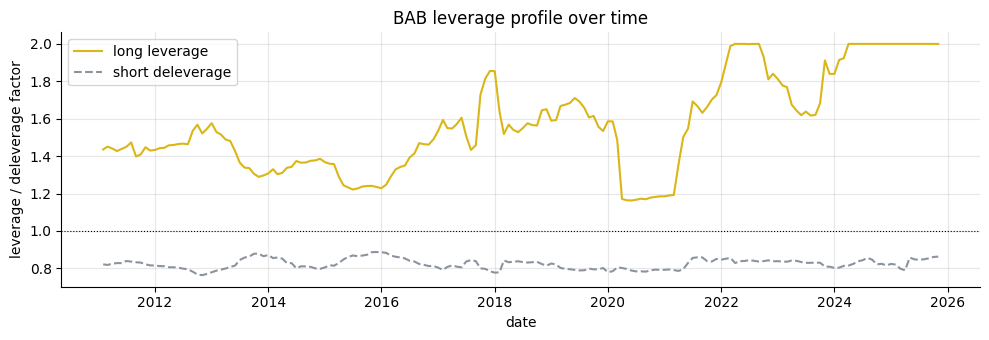

Avg leverage: 1.57x | Avg deleverage: 0.82x


In [7]:
# Leverage profile over time (synthetic for offline demo)
if HAVE_REAL:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.plot(result.index, result['leverage'], c=AMBER, lw=1.5, label='long leverage')
    ax.plot(result.index, result['deleverage'], c=GREY, lw=1.5, ls='--',
            label='short deleverage')
    ax.axhline(1.0, c='k', lw=0.8, ls=':')
    ax.set_ylabel('leverage / deleverage factor')
    ax.set_xlabel('date')
    ax.set_title('BAB leverage profile over time')
    ax.legend(); plt.tight_layout(); plt.show()
    print(f'Avg leverage: {result["leverage"].mean():.2f}x | '
          f'Avg deleverage: {result["deleverage"].mean():.2f}x')
else:
    print(f'Frozen: avg leverage={R["avg_leverage"]:.2f}x | '
          f'avg deleverage={R["avg_deleverage"]:.2f}x')

## 7 -- Going further

- **Broader universe.** Frazzini-Pedersen (2014) used all US stocks from 1984. The premium is strongest in small/mid-cap where leverage constraints bind more.
- **Cross-asset BAB.** The paper documents BAB in bonds, FX, and commodities. A multi-asset test (without equity survivorship bias) would be more informative.
- **Net of financing costs.** Explicitly model the borrowing spread (e.g., LIBOR/SOFR + 50bps for margin). This can significantly reduce the net premium.
- **Low-volatility variant.** Sort by realised volatility instead of beta. Similar results with less leverage required.
- **[Study 144 -- Permanent Portfolio](../../144-permanent-portfolio/)**: a risk-parity-adjacent multi-asset allocation that avoids equity beta concentration.
- **[Study 122 -- Gross-Profitability](../../122-gross-profitability/)**: quality factor using the same desk infrastructure (rolling sort, equal-weight, HAC inference).

*Think BAB survives in large-caps net of financing costs? Fork this, add a realistic borrowing spread, expand to Russell 3000, and show t > 2 net of costs. That is the bar.*